In [19]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from scipy.signal import savgol_filter

ROOT = Path.cwd().resolve()
CSV_DIR = ROOT / "data" / "csv_dir"
DROPS_CSV = ROOT / "reports_type" / "historical_drops.csv"

plt.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 150
})

def kalman_1d(y, q=1e-5, r=1e-2):
    n = len(y)
    x, p = np.zeros(n), np.zeros(n)
    x[0], p[0] = y[0], 1.0
    for k in range(1, n):
        x_pred, p_pred = x[k - 1], p[k - 1] + q
        kk = p_pred / (p_pred + r)
        x[k] = x_pred + kk * (y[k] - x_pred)
        p[k] = (1 - kk) * p_pred
    return x

def load_csv(name):
    df = pd.read_csv(CSV_DIR / name, parse_dates=["time"])
    return df.sort_values("time").reset_index(drop=True)

def _slice_around(df, ts, before_min, after_min):
    return df[(df["time"] >= ts - pd.Timedelta(minutes=before_min)) &
              (df["time"] <= ts + pd.Timedelta(minutes=after_min))].copy()

def format_duration(minutes):
    if pd.isna(minutes): return "Неизвестно"
    if minutes >= 60: return f"{int(minutes // 60)} ч {int(minutes % 60)} мин"
    return f"{int(minutes)} мин"

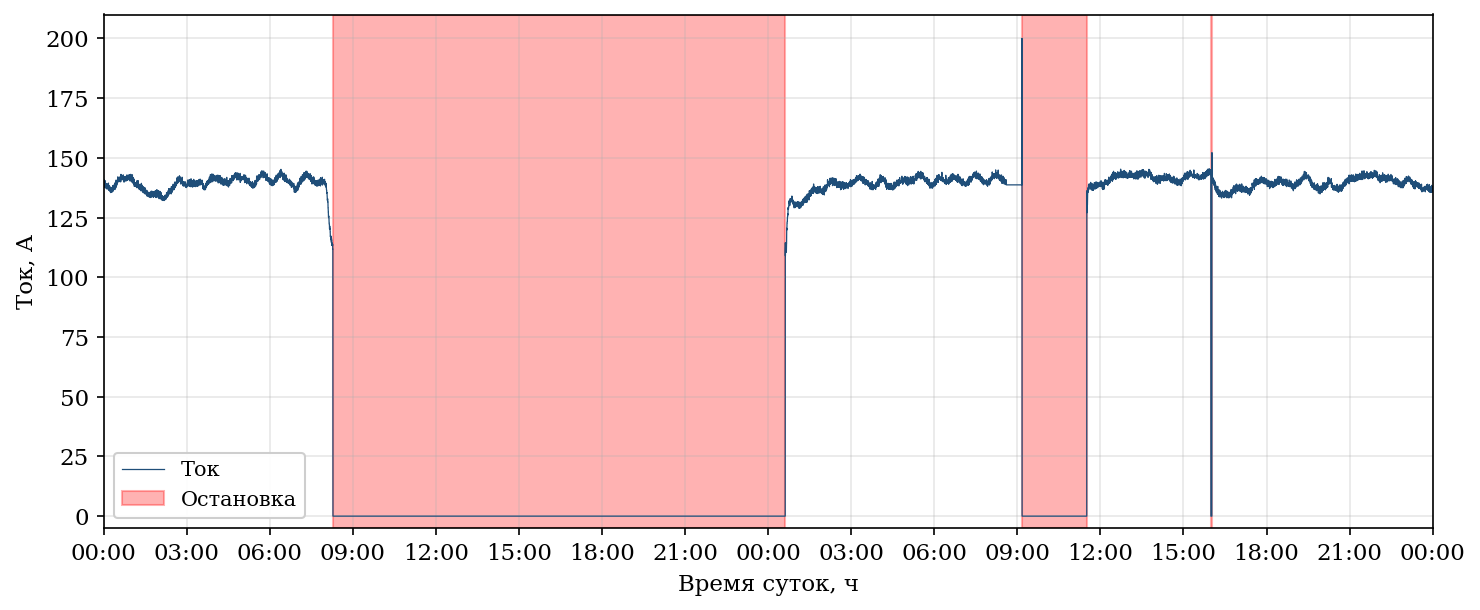

In [20]:
fname = "1sect_05.09-20.09.24.csv"
df = load_csv(fname)
drops = pd.read_csv(DROPS_CSV, parse_dates=["drop_start", "stop_start"])
drops = drops[drops["filename"] == fname]

t0 = pd.Timestamp("2024-09-16 00:00")
t1 = pd.Timestamp("2024-09-18 00:00")
sub = df[(df["time"] >= t0) & (df["time"] < t1)].copy()
drops_day = drops[(drops["stop_start"] >= t0) & (drops["stop_start"] < t1)]

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(sub["time"], sub["current"], color="#1f4e79", lw=0.6, label="Ток")

for i, (_, row) in enumerate(drops_day.iterrows()):
    ts_stop = row["stop_start"]
    ts_stop_end = ts_stop + pd.Timedelta(minutes=float(row["stop_duration"]))
    label = "Остановка" if i == 0 else None
    ax.axvspan(ts_stop, ts_stop_end, color="red", alpha=0.3, label=label)

ax.legend(loc="lower left", framealpha=0.95)
ax.set_xlabel("Время суток, ч")
ax.set_ylabel("Ток, А")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax.grid(True, alpha=0.3)
ax.set_xlim(t0, t1)
ax.set_ylim(bottom=-5)

fig.tight_layout()
plt.show()

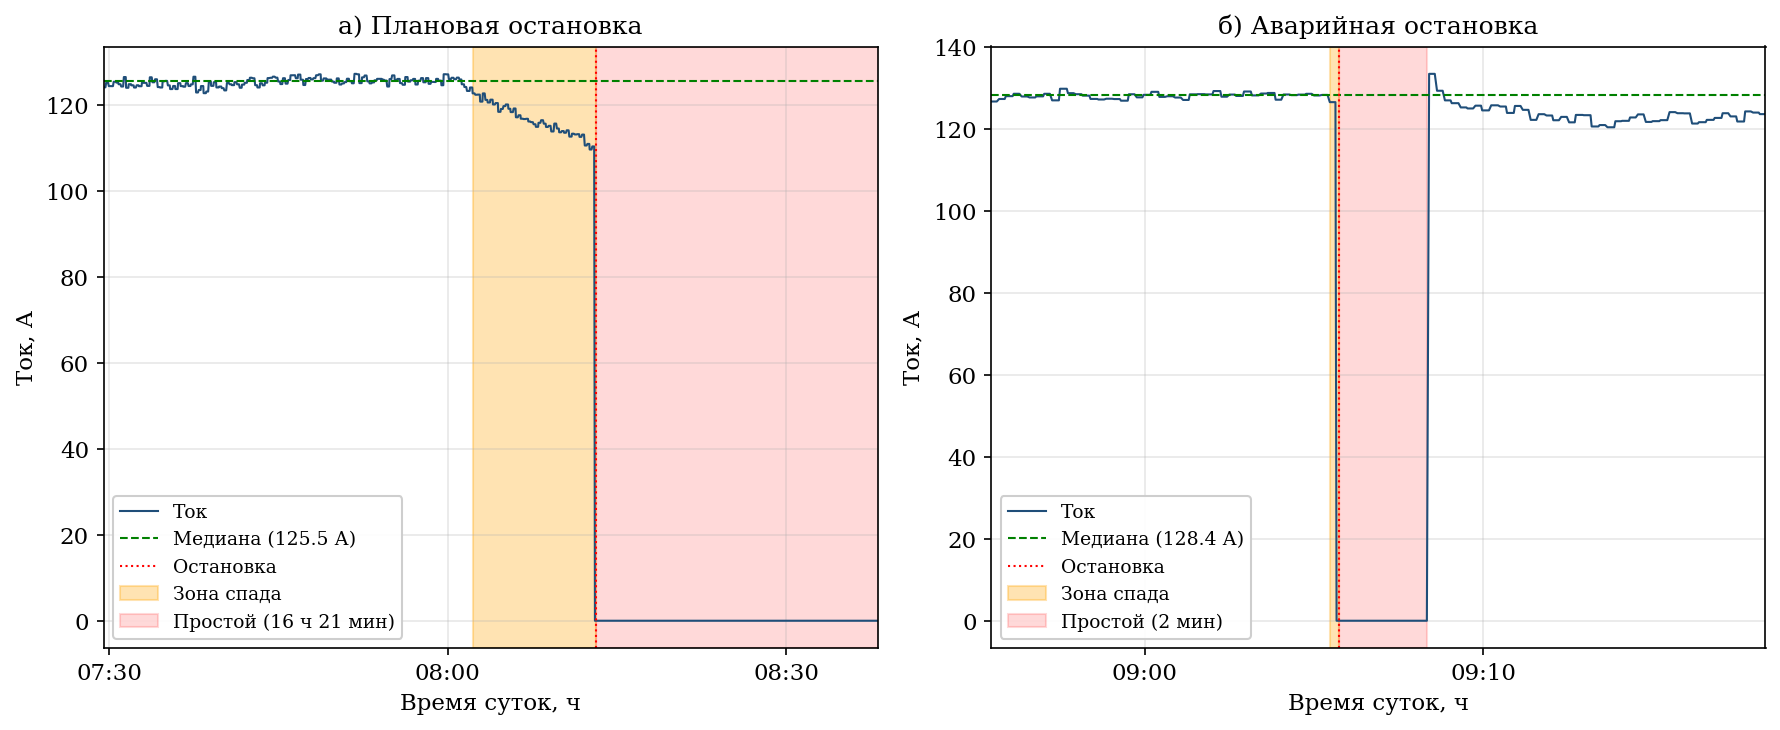

In [21]:
drops = pd.read_csv(DROPS_CSV, parse_dates=["drop_start", "stop_start"])

plan = drops[(drops["stop_type"] == "ПЛАНОВАЯ") & (drops["drop_duration"] > 5) &
             (drops["drop_duration"] < 12) & (drops["start_current"] > 120)].iloc[0]

em = drops[(drops["stop_type"] == "АВАРИЙНАЯ") & (drops["drop_duration"] < 0.3) &
           (drops["start_current"] > 100)].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
date_form = mdates.DateFormatter("%H:%M")

for ax, row, title in [(axes[0], plan, "а) Плановая остановка"), (axes[1], em, "б) Аварийная остановка")]:
    df = load_csv(row["filename"])
    ts_drop, ts_stop = row["drop_start"], row["stop_start"]
    stop_dur_mins = float(row["stop_duration"])

    before = max(10, min(60, 3 * float(row["drop_duration"])))
    after = float(row["drop_duration"]) + min(stop_dur_mins, 15) + 10

    sub = _slice_around(df, ts_drop, before, after)
    if sub.empty: continue

    sub["t_rel"] = (sub["time"] - ts_drop).dt.total_seconds() / 60.0
    median_current = sub[(sub["t_rel"] < 0) & (sub["t_rel"] > -before * 0.8)]["current"].median()

    ax.plot(sub["time"], sub["current"], color="#1f4e79", lw=1, label="Ток")
    ax.axhline(y=median_current, color='g', linestyle='--', lw=1, label=f'Медиана ({median_current:.1f} А)')
    ax.axvline(ts_stop, color='r', linestyle=':', lw=1, label='Остановка')
    ax.axvspan(ts_drop, ts_stop, color='orange', alpha=0.3, label='Зона спада')
    ax.axvspan(ts_stop, ts_stop + pd.Timedelta(minutes=stop_dur_mins),
               color='red', alpha=0.15, label=f'Простой ({format_duration(stop_dur_mins)})')

    ax.set_title(title)
    ax.set_xlabel("Время суток, ч")
    ax.set_ylabel("Ток, А")
    ax.set_xlim(sub["time"].min(), sub["time"].max())
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=3, maxticks=5))
    ax.xaxis.set_major_formatter(date_form)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower left", fontsize=9, framealpha=0.95)

fig.tight_layout()
plt.show()

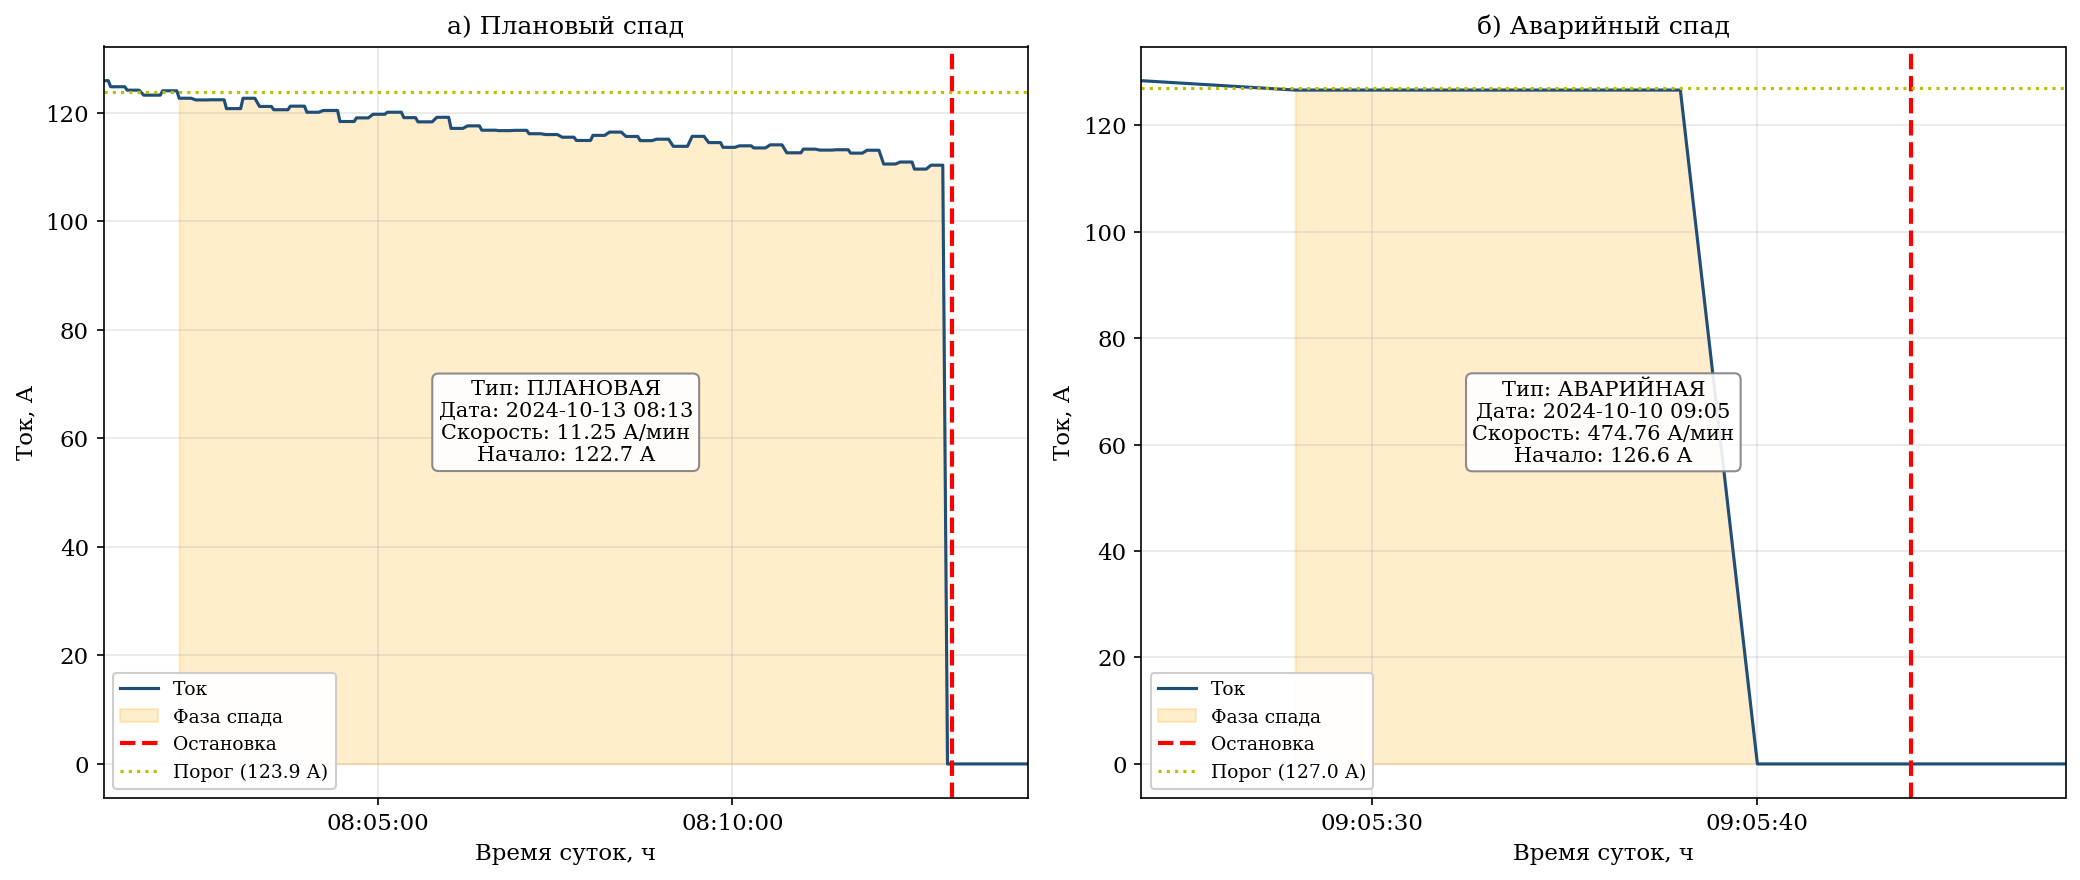

In [22]:
drops = pd.read_csv(DROPS_CSV, parse_dates=["drop_start", "stop_start"])

plan = drops[(drops["stop_type"] == "ПЛАНОВАЯ") & (drops["drop_duration"] > 5) &
             (drops["drop_duration"] < 12) & (drops["start_current"] > 120)].iloc[0]

em = drops[(drops["stop_type"] == "АВАРИЙНАЯ") & (drops["drop_duration"] < 0.3) &
           (drops["start_current"] > 100)].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
date_form = mdates.DateFormatter("%H:%M:%S")

for ax, row, title in [(axes[0], plan, "а) Плановый спад"), (axes[1], em, "б) Аварийный спад")]:
    df = load_csv(row["filename"])
    ts_drop, ts_stop = row["drop_start"], row["stop_start"]
    dur_sec = (ts_stop - ts_drop).total_seconds()
    pad_sec = max(5, dur_sec * 0.1)

    before_mins = max(10, min(60, 3 * float(row["stop_duration"])))
    norm_df = df[(df['time'] >= ts_drop - pd.Timedelta(minutes=before_mins)) &
                 (df['time'] <= ts_drop - pd.Timedelta(minutes=before_mins * 0.2))]
    start_threshold = norm_df["current"].median() - 1.5 * norm_df["current"].std() if not norm_df.empty else None

    drop_zone = df[(df['time'] >= ts_drop - pd.Timedelta(seconds=pad_sec)) &
                   (df['time'] <= ts_stop + pd.Timedelta(seconds=pad_sec))]
    actual_drop = drop_zone[(drop_zone['time'] >= ts_drop) & (drop_zone['time'] <= ts_stop)]

    if drop_zone.empty: continue

    ax.plot(drop_zone['time'], drop_zone['current'], color="#1f4e79", lw=1.5, label="Ток")
    ax.fill_between(actual_drop['time'], actual_drop['current'], color='orange', alpha=0.2, label='Фаза спада')
    ax.axvline(ts_stop, color='r', linestyle='--', lw=2, label='Остановка')

    if start_threshold:
        ax.axhline(y=start_threshold, color='y', linestyle=':', lw=1.5, label=f'Порог ({start_threshold:.1f} А)')

    if not actual_drop.empty:
        c_start = actual_drop['current'].iloc[0]
        drop_speed = ((c_start - actual_drop['current'].iloc[-1]) / dur_sec) * 60 if dur_sec > 0 else 0
        info_text = (f'Тип: {row["stop_type"]}\nДата: {ts_stop.strftime("%Y-%m-%d %H:%M")}\n'
                     f'Скорость: {drop_speed:.2f} А/мин\nНачало: {c_start:.1f} А')

        ax.annotate(info_text, xy=(ts_drop + pd.Timedelta(seconds=dur_sec/2),
                    (drop_zone['current'].max() + drop_zone['current'].min()) / 2),
                    ha='center', va='center', bbox=dict(boxstyle='round', fc='w', alpha=0.9, ec='gray'), fontsize=10)

    ax.set_title(title)
    ax.set_ylabel('Ток, А')
    ax.set_xlabel('Время суток, ч')
    ax.set_xlim(drop_zone['time'].min(), drop_zone['time'].max())
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=3, maxticks=5))
    ax.xaxis.set_major_formatter(date_form)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower left", fontsize=9, framealpha=0.95)

fig.tight_layout()
plt.show()

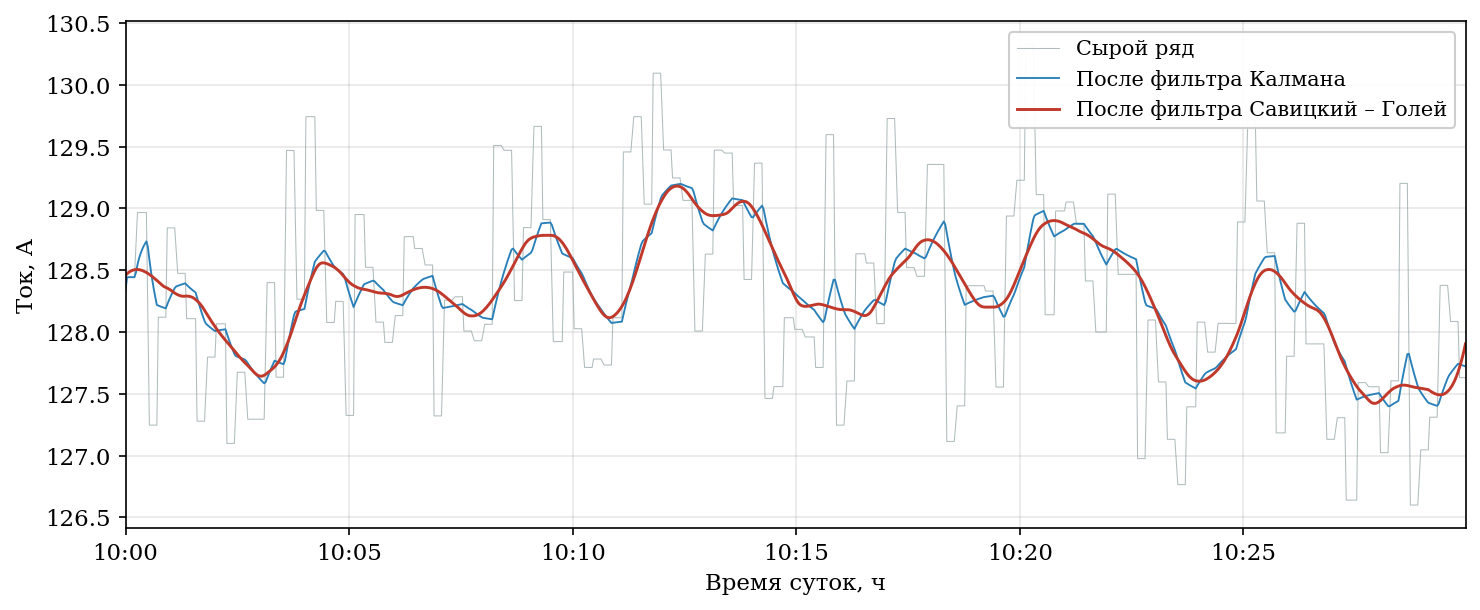

In [23]:
fname = "1sect_05.10-20.10.24.csv"
df = load_csv(fname)

t0 = pd.Timestamp("2024-10-08 10:00")
t1 = t0 + pd.Timedelta(minutes=30)
sub = df[(df["time"] >= t0) & (df["time"] < t1)].dropna(subset=["current"]).reset_index(drop=True)

raw = sub["current"].values.astype(float)

kf = kalman_1d(raw, q=1e-5, r=1e-2 * raw.var())
win = max(5, 51 if len(raw) >= 51 else (len(raw) // 2) * 2 + 1)
sg = savgol_filter(kf, window_length=win, polyorder=3)

fig, ax = plt.subplots(figsize=(10, 4.2))

ax.plot(sub["time"], raw, color="#95a5a6", lw=0.5, alpha=0.75, label="Сырой ряд")
ax.plot(sub["time"], kf, color="#2980b9", lw=0.9, label="После фильтра Калмана")
ax.plot(sub["time"], sg, color="#c0392b", lw=1.4, label="После фильтра Савицкий – Голей")

ax.set_xlabel("Время суток, ч")
ax.set_ylabel("Ток, А")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", framealpha=0.95)

ax.set_xlim(sub["time"].min(), sub["time"].max())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))

fig.tight_layout()
plt.show()

In [25]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
ALL_SHIFTS = ROOT / "reports_mode" / "all_shifts.csv"
SUMMARY = ROOT / "reports_mode" / "summary.json"
df = pd.read_csv(ALL_SHIFTS)

with open(SUMMARY, "r", encoding="utf-8") as f:
    summary = json.loads(f.read())

df = df.sort_values("end_time").reset_index(drop=True)

n_train = int(len(df) * summary["config"]["train_split_frac"])
df["split"] = ["train"] * n_train + ["test"] * (len(df) - n_train)

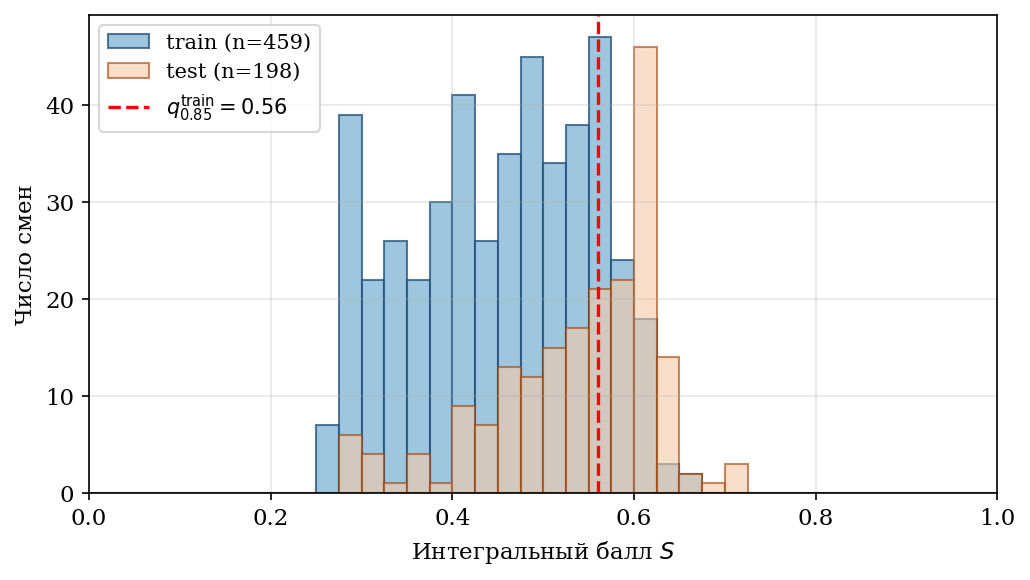

In [26]:
train = df[df["split"] == "train"]
s_train = train["score"].values
s_test = df[df["split"] == "test"]["score"].values

top_q = float(np.quantile(s_train, 0.85))

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 1, 41)

ax.hist(s_train, bins=bins, color="#7fb3d5", edgecolor="#1f4e79",
        alpha=0.75, label=f"train (n={len(s_train)})")
ax.hist(s_test, bins=bins, color="#f5cba7", edgecolor="#a04000",
        alpha=0.6, label=f"test (n={len(s_test)})")

ax.axvline(top_q, color="red", ls="--", lw=1.6,
           label=fr"$q_{{0.85}}^{{\mathrm{{train}}}} = {top_q:.2f}$")

ax.set_xlabel(r"Интегральный балл $S$")
ax.set_ylabel("Число смен")
ax.grid(alpha=0.3)
ax.legend(loc="upper left")
ax.set_xlim(0, 1)

fig.tight_layout()
plt.show()

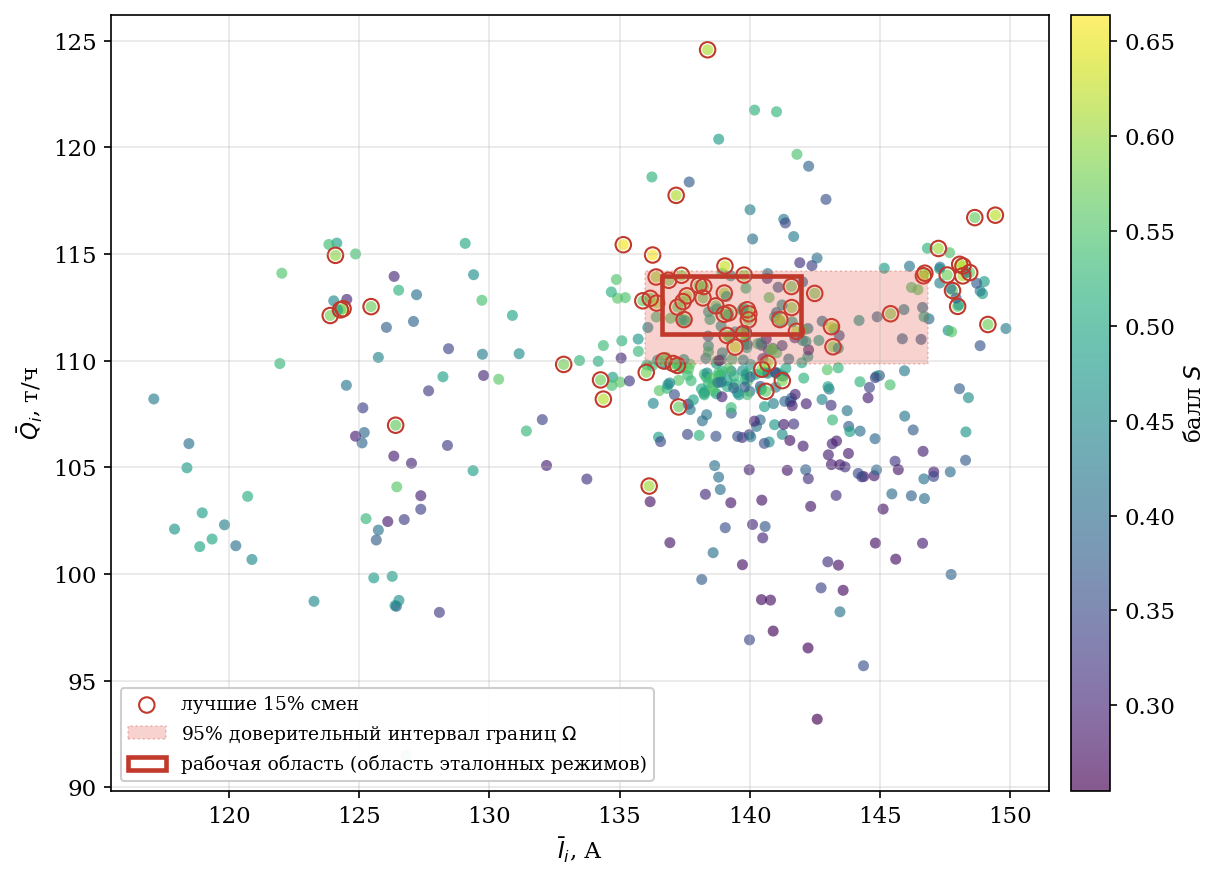

In [27]:
from matplotlib.patches import Rectangle

wa = summary["working_area"]
train = df[df["split"] == "train"]

top_q = float(np.quantile(train["score"], 1 - wa["top_frac"]))
is_top = train["score"] >= top_q

fig, ax = plt.subplots(figsize=(8.5, 6))

sc = ax.scatter(train["current_mean"], train["weight_mean"], c=train["score"], cmap="viridis", s=28, alpha=0.65, edgecolor="none")
cb = plt.colorbar(sc, ax=ax, pad=0.02)
cb.set_label(r"балл $S$")

ax.scatter(train.loc[is_top, "current_mean"], train.loc[is_top, "weight_mean"], s=55, facecolor="none", edgecolor="#c0392b", lw=1, label=fr"лучшие 15% смен")

i_lo_ci, i_hi_ci = wa["current"]["p25_ci"][0], wa["current"]["p75_ci"][1]
q_lo_ci, q_hi_ci = wa["weight"]["p25_ci"][0], wa["weight"]["p75_ci"][1]
ax.add_patch(Rectangle((i_lo_ci, q_lo_ci), i_hi_ci - i_lo_ci, q_hi_ci - q_lo_ci, fill=True, facecolor="#e74c3c", alpha=0.25, edgecolor="#c0392b", lw=0.9, ls=":", label=r"95% доверительный интервал границ $\Omega$"))

i_lo, i_hi = wa["current"]["p25"], wa["current"]["p75"]
q_lo, q_hi = wa["weight"]["p25"], wa["weight"]["p75"]
ax.add_patch(Rectangle((i_lo, q_lo), i_hi - i_lo, q_hi - q_lo, fill=False, edgecolor="#c0392b", lw=2.2, label=r"рабочая область (область эталонных режимов)"))

ax.set_xlabel(r"$\bar I_i$, А")
ax.set_ylabel(r"$\bar Q_i$, т/ч")
ax.grid(alpha=0.3)
ax.legend(loc="lower left", fontsize=9, framealpha=0.95)

fig.tight_layout()
plt.show()